Wczytywanie danych...

--- WYNIKI ---
[SYNTETYK] Ilość: 101258, Czas: 0.298s
[REALNY]   Ilość: 73762, Czas: 0.299s
STOSUNEK ILOŚCI ZDARZEŃ: 1.37 (Cel: ~1.0)
PODOBIEŃSTWO STRUKTURALNE (SSIM): 0.2015


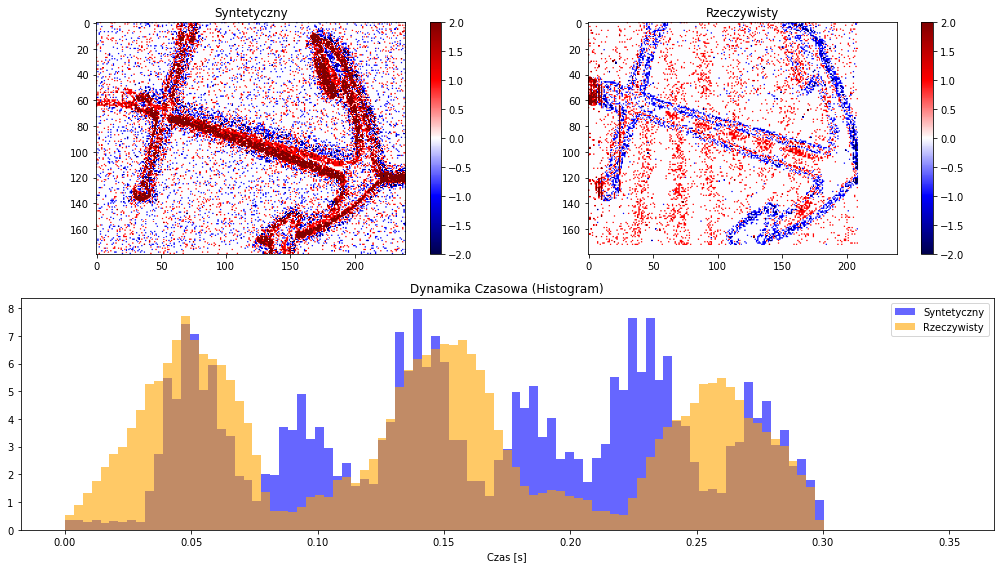

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import cv2
from skimage.metrics import structural_similarity as ssim

# ================= KONFIGURACJA =================
# Upewnij się, że ścieżki są poprawne!
SYNTH_FILE = r'C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS\anchor\image_0008.h5'
REAL_FILE = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101\NCALTECH101\Caltech101\anchor\image_0008.bin"

WIDTH, HEIGHT = 240, 180
# ================================================

def load_h5(path):
    """Bezpieczne wczytywanie H5 z konwersją typów"""
    if not os.path.exists(path):
        print(f"Błąd: Nie znaleziono pliku {path}")
        return None
    
    try:
        with h5py.File(path, 'r') as f:
            # Wczytujemy dane surowe
            raw_events = f['events'][:] 
            
        # Konwersja na float64 (to naprawia Twój błąd!)
        # Tworzymy nową tablicę, zamiast modyfikować starą w miejscu
        events = raw_events.astype(np.float64)

        # Naprawa czasu (us -> s)
        if len(events) > 0:
            # Jeśli czas jest duży (mikrosekundy), dzielimy
            if events[-1, 0] > 1000: 
                events[:, 0] /= 1e6
            
            # Przesuwamy start do 0.0s
            events[:, 0] -= events[0, 0]
            
        return events
    except Exception as e:
        print(f"Krytyczny błąd wczytywania H5: {e}")
        return None

def load_bin(path):
    """Wczytywanie formatu N-Caltech .bin"""
    if not os.path.exists(path):
        print(f"Błąd: Nie znaleziono pliku {path}")
        return None

    try:
        with open(path, 'rb') as f:
            raw = np.fromfile(f, dtype=np.uint8)
        
        # Wyrównanie do 5 bajtów
        raw = raw[:len(raw)//5*5]
        
        x = raw[0::5]
        y = raw[1::5]
        p = (raw[2::5] >> 7) & 1
        
        # Dekodowanie czasu (Big Endian 4 bajty z maskowaniem)
        t_high = (raw[2::5] & 0x7f).astype(np.uint32)
        t_mid = raw[3::5].astype(np.uint32)
        t_low = raw[4::5].astype(np.uint32)
        ts_us = ((t_high << 16) | (t_mid << 8) | t_low)
        
        # Konwersja na float sekundy
        ts = ts_us.astype(np.float64) / 1e6
        
        # Złożenie w jedną macierz
        events = np.column_stack((ts, x, y, p))
        
        # Normalizacja czasu
        if len(events) > 0:
            events[:, 0] -= events[0, 0]
            
        return events
    except Exception as e:
        print(f"Błąd BIN: {e}")
        return None

def create_frame(events, shape):
    """Tworzy obraz 2D (zabezpieczony przed IndexError)"""
    img = np.zeros(shape, dtype=np.float32)
    if events is None or len(events) == 0: return img
    
    x = events[:, 1].astype(int)
    y = events[:, 2].astype(int)
    p = events[:, 3]
    
    # Kluczowe zabezpieczenie indeksów
    mask = (x >= 0) & (x < shape[1]) & (y >= 0) & (y < shape[0])
    
    x = x[mask]
    y = y[mask]
    p = p[mask]
    
    vals = np.where(p==1, 1, -1)
    np.add.at(img, (y, x), vals)
    
    return img

def compare_datasets():
    print("Wczytywanie danych...")
    ev_syn = load_h5(SYNTH_FILE)
    ev_real = load_bin(REAL_FILE)

    if ev_syn is None:
        print("Brak danych syntetycznych. Sprawdź ścieżkę.")
        return
    if ev_real is None:
        print("Brak danych rzeczywistych. Sprawdź ścieżkę.")
        # Kontynuujemy, żeby pokazać chociaż syntetyk
    
    # --- STATYSTYKI ---
    print("\n--- WYNIKI ---")
    count_syn = len(ev_syn)
    dur_syn = ev_syn[-1,0] - ev_syn[0,0] if count_syn > 0 else 0
    print(f"[SYNTETYK] Ilość: {count_syn}, Czas: {dur_syn:.3f}s")
    
    if ev_real is not None:
        count_real = len(ev_real)
        dur_real = ev_real[-1,0] - ev_real[0,0] if count_real > 0 else 0
        print(f"[REALNY]   Ilość: {count_real}, Czas: {dur_real:.3f}s")
        print(f"STOSUNEK ILOŚCI ZDARZEŃ: {count_syn/count_real:.2f} (Cel: ~1.0)")

        # Przycinamy syntetyk do czasu rzeczywistego dla wykresów
        max_t = min(dur_syn, dur_real)
        ev_syn_plot = ev_syn[ev_syn[:,0] <= max_t]
        ev_real_plot = ev_real[ev_real[:,0] <= max_t]
    else:
        ev_syn_plot = ev_syn
        ev_real_plot = None

    # --- WIZUALIZACJA ---
    plt.figure(figsize=(14, 8))
    
    # 1. Obrazy
    img_syn = create_frame(ev_syn, (HEIGHT, WIDTH))
    plt.subplot(2, 2, 1)
    plt.imshow(img_syn, cmap='seismic', vmin=-2, vmax=2)
    plt.title("Syntetyczny")
    plt.colorbar()

    if ev_real is not None:
        img_real = create_frame(ev_real, (HEIGHT, WIDTH))
        plt.subplot(2, 2, 2)
        plt.imshow(img_real, cmap='seismic', vmin=-2, vmax=2)
        plt.title("Rzeczywisty")
        plt.colorbar()
        
        # Oblicz SSIM (normalizacja 0-255)
        norm_syn = cv2.normalize(img_syn, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        norm_real = cv2.normalize(img_real, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        score, _ = ssim(norm_syn, norm_real, full=True)
        print(f"PODOBIEŃSTWO STRUKTURALNE (SSIM): {score:.4f}")

    # 2. Histogramy Czasowe
    plt.subplot(2, 1, 2)
    bins = np.linspace(0, 0.35, 100)
    
    plt.hist(ev_syn_plot[:, 0], bins=bins, alpha=0.6, label='Syntetyczny', color='blue', density=True)
    if ev_real_plot is not None:
        plt.hist(ev_real_plot[:, 0], bins=bins, alpha=0.6, label='Rzeczywisty', color='orange', density=True)
    
    plt.title("Dynamika Czasowa (Histogram)")
    plt.xlabel("Czas [s]")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

compare_datasets()

In [22]:
import os
import numpy as np
import struct
from scipy.stats import entropy
from scipy.spatial.distance import cdist
from tqdm import tqdm
from scipy.stats import wasserstein_distance

# ------------------------------
# LOADER 1: Dla danych Syntetycznych (7 bajtów)
# ------------------------------
def load_synth_bin(path):
    if not os.path.exists(path): return np.array([])
    
    # Format z poprzedniego skryptu: x(u1), y(u1), p(u1), t(>u4)
    dt = np.dtype([('x', 'u1'), ('y', 'u1'), ('p', 'u1'), ('t', '>u4')])
    
    try:
        data = np.fromfile(path, dtype=dt)
        # Konwersja na standardowy format [x, y, t, p]
        # t zamieniamy na mikrosekundy (int) lub zostawiamy
        events = np.zeros((len(data), 4), dtype=np.float32)
        events[:, 0] = data['x']
        events[:, 1] = data['y']
        events[:, 2] = data['t']
        # Zamiana p=0/1 na -1/1
        events[:, 3] = np.where(data['p'] == 1, 1, -1)
        
        return events
    except Exception as e:
        print(f"Błąd odczytu Synth {path}: {e}")
        return np.array([])

# ------------------------------
# LOADER 2: Dla danych Rzeczywistych N-Caltech (5 bajtów)
# ------------------------------
def load_real_bin(path):
    if not os.path.exists(path): return np.array([])
    
    try:
        with open(path, 'rb') as f:
            raw = np.fromfile(f, dtype=np.uint8)
            
        # Wyrównanie do 5 bajtów
        raw = raw[:len(raw)//5*5]
        
        x = raw[0::5]
        y = raw[1::5]
        p = (raw[2::5] >> 7) & 1
        
        t_high = (raw[2::5] & 0x7f).astype(np.uint32)
        t_mid = raw[3::5].astype(np.uint32)
        t_low = raw[4::5].astype(np.uint32)
        ts = ((t_high << 16) | (t_mid << 8) | t_low)
        
        events = np.zeros((len(x), 4), dtype=np.float32)
        events[:, 0] = x
        events[:, 1] = y # Czasem w N-Caltech trzeba dać: 179 - y
        events[:, 2] = ts
        events[:, 3] = np.where(p == 1, 1, -1)
        
        return events
    except Exception as e:
        print(f"Błąd odczytu Real {path}: {e}")
        return np.array([])

# ------------------------------
# Metryki (Bez zmian, tylko drobne zabezpieczenia)
# ------------------------------
def event_count_ratio(real, synth):
    if len(real) == 0: return np.nan
    return len(synth) / len(real)

def polarity_balance_error(events):
    if len(events) == 0: return np.nan
    pos = np.sum(events[:, 3] > 0)
    neg = np.sum(events[:, 3] < 0)
    return abs(pos - neg) / (pos + neg + 1e-9)

from scipy.stats import wasserstein_distance, entropy

# ================================
# POPRAWIONY EMD (Wasserstein 1D)
# ================================
def spatial_emd(real, synth, bins=32):
    if len(real) == 0 or len(synth) == 0:
        return np.nan

    # Histogram 2D dla pozycji (x, y)
    H_real, _, _ = np.histogram2d(
        real[:,0], real[:,1],
        bins=bins,
        range=[[0,240], [0,180]]
    )
    H_synth, _, _ = np.histogram2d(
        synth[:,0], synth[:,1],
        bins=bins,
        range=[[0,240], [0,180]]
    )

    # Spłaszczenie
    h1 = H_real.flatten().astype(np.float64)
    h2 = H_synth.flatten().astype(np.float64)

    # Normalizacja
    h1 /= (h1.sum() + 1e-9)
    h2 /= (h2.sum() + 1e-9)

    # Wasserstein distance (prawdziwy EMD)
    return float(wasserstein_distance(h1, h2))

# ================================
# POPRAWIONY IEI-KL
# ================================
def iei_kl(events_real, events_synth, bins=100):
    if len(events_real) < 2 or len(events_synth) < 2:
        return np.nan

    t_real = np.sort(events_real[:, 2].astype(np.float64))
    t_synth = np.sort(events_synth[:, 2].astype(np.float64))

    dt_real = np.diff(t_real)
    dt_synth = np.diff(t_synth)

    # Minimalne czyszczenie
    dt_real = dt_real[dt_real > 0]
    dt_synth = dt_synth[dt_synth > 0]

    if len(dt_real) < 5 or len(dt_synth) < 5:
        return np.nan

    min_val = min(dt_real.min(), dt_synth.min())
    max_val = max(dt_real.max(), dt_synth.max())

    if min_val <= 0 or max_val <= min_val:
        return np.nan

    bins_log = np.logspace(np.log10(min_val), np.log10(max_val), bins)

    P, _ = np.histogram(dt_real, bins=bins_log, density=True)
    Q, _ = np.histogram(dt_synth, bins=bins_log, density=True)

    P += 1e-12
    Q += 1e-12
    P /= P.sum()
    Q /= Q.sum()

    return float(entropy(P, Q))

# ------------------------------
# Główna pętla
# ------------------------------
def compute_metrics_for_class(real_dir, synth_dir, n_files=60):
    # Pobieramy tylko .bin
    real_files = sorted([os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith(".bin")])[:n_files]
    synth_files = sorted([os.path.join(synth_dir, f) for f in os.listdir(synth_dir) if f.endswith(".bin")])[:n_files]

    metrics = {"ECR": [], "PBE_real": [], "PBE_synth": [], "EMD": [], "IEI_KL": []}

    print(f"Przetwarzanie {len(real_files)} par plików...")
    
    for rf, sf in tqdm(zip(real_files, synth_files), total=len(real_files)):
        real = load_real_bin(rf)   # <--- Loader 5 bajtów
        synth = load_synth_bin(sf) # <--- Loader 7 bajtów

        metrics["ECR"].append(event_count_ratio(real, synth))
        metrics["PBE_real"].append(polarity_balance_error(real))
        metrics["PBE_synth"].append(polarity_balance_error(synth))
        metrics["EMD"].append(spatial_emd(real, synth))
        metrics["IEI_KL"].append(iei_kl(real, synth))

    return {k: float(np.nanmean(v)) for k, v in metrics.items()}

if __name__ == "__main__":
    # UPEWNIJ SIĘ, ŻE ŚCIEŻKI SĄ DOBRE
    real_class = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101\NCALTECH101\Caltech101\yin_yang"
    synth_class = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS\yin_yang"

    if os.path.exists(real_class) and os.path.exists(synth_class):
        results = compute_metrics_for_class(real_class, synth_class)
        print("\n=== WYNIKI METRYK ===")
        for k, v in results.items():
            print(f"{k}: {v:.4f}")
    else:
        print("Błąd: Sprawdź ścieżki do folderów!")

Przetwarzanie 60 par plików...


100%|██████████████████████████████████████████████████████████████████████████████████| 60/60 [00:02<00:00, 29.03it/s]


=== WYNIKI METRYK ===
ECR: 1.7037
PBE_real: 0.0254
PBE_synth: 0.1561
EMD: 0.0002
IEI_KL: 13.5195


In [27]:
# ============================================================
# EVENT-BASED DATA ANALYSIS: v2e vs N-Caltech101
# Kompletny pipeline: loader .bin + statystyki
# ============================================================

import os
import numpy as np
from scipy.stats import entropy, skew, wasserstein_distance
from tqdm import tqdm

# ============================================================
# 1. LOADERY .BIN
# ============================================================

def load_synth_bin(path):
    """
    Synthetic DVS (v2e)
    Format: x(u1), y(u1), p(u1), t(>u4)
    """
    if not os.path.exists(path):
        return np.empty((0, 4), dtype=np.float32)

    dt = np.dtype([
        ('x', 'u1'),
        ('y', 'u1'),
        ('p', 'u1'),
        ('t', '>u4')
    ])

    try:
        data = np.fromfile(path, dtype=dt)
        events = np.zeros((len(data), 4), dtype=np.float64)
        events[:, 0] = data['x']
        events[:, 1] = data['y']
        events[:, 2] = data['t']
        events[:, 3] = np.where(data['p'] == 1, 1, -1)
        return events
    except Exception as e:
        print(f"[ERROR] Synth loader: {path} -> {e}")
        return np.empty((0, 4), dtype=np.float32)


def load_real_bin(path):
    """
    Real N-Caltech101
    Format: 5 bytes / event
    """
    if not os.path.exists(path):
        return np.empty((0, 4), dtype=np.float64)

    try:
        raw = np.fromfile(path, dtype=np.uint8)
        raw = raw[:len(raw)//5 * 5]

        x = raw[0::5]
        y = raw[1::5]

        p = (raw[2::5] >> 7) & 1
        t_high = (raw[2::5] & 0x7F).astype(np.uint32)
        t_mid  = raw[3::5].astype(np.uint32)
        t_low  = raw[4::5].astype(np.uint32)

        ts = (t_high << 16) | (t_mid << 8) | t_low

        events = np.zeros((len(x), 4), dtype=np.float64)
        events[:, 0] = x
        events[:, 1] = y  # opcjonalnie: 179 - y
        events[:, 2] = ts
        events[:, 3] = np.where(p == 1, 1, -1)
        return events
    except Exception as e:
        print(f"[ERROR] Real loader: {path} -> {e}")
        return np.empty((0, 4), dtype=np.float32)
    
def normalize_time(events):
    if len(events) == 0:
        return events

    t = events[:, 2].astype(np.float64)
    t -= t.min()
    events[:, 2] = t
    events[:, 2] *= 1e-6  # µs → s
    return events



# ============================================================
# 2. STATYSTYKI GLOBALNE
# ============================================================

def global_stats(events):
    if len(events) < 2:
        return {}

    t = events[:, 2].astype(np.float64)
    p = events[:, 3]

    duration = t.max() - t.min() + 1e-9
    rate = len(events) / duration

    pos = np.sum(p > 0)
    neg = np.sum(p < 0)

    return {
        "duration": duration,
        "event_rate": rate,
        "on_off_ratio": pos / (neg + 1e-9)
    }

# ============================================================
# 3. STATYSTYKI PRZESTRZENNE
# ============================================================

def spatial_stats(events, sensor_size=(180, 240), bins=32):
    if len(events) == 0:
        return {}

    x, y = events[:, 0], events[:, 1]
    H, W = sensor_size

    density, _, _ = np.histogram2d(
        y, x,
        bins=bins,
        range=[[0, H], [0, W]]
    )

    sparsity = np.count_nonzero(density) / density.size

    p = density.flatten()
    p = p[p > 0]
    p /= p.sum()

    return {
        "sparsity": sparsity,
        "spatial_entropy": entropy(p)
    }

def spatial_moments(events):
    if len(events) == 0:
        return {}

    return {
        "centroid_x": np.mean(events[:, 0]),
        "centroid_y": np.mean(events[:, 1]),
        "var_x": np.var(events[:, 0]),
        "var_y": np.var(events[:, 1])
    }

# ============================================================
# 4. STATYSTYKI CZASOWE
# ============================================================

def iei_stats(events):
    if len(events) < 3:
        return {}

    t = np.sort(events[:, 2])
    dt = np.diff(t)
    dt = dt[dt > 0]

    if len(dt) < 5:
        return {}

    return {
        "iei_mean": np.mean(dt),
        "iei_std": np.std(dt),
        "iei_skew": skew(dt)
    }

def iei_wasserstein(real, synth):
    if len(real) < 3 or len(synth) < 3:
        return np.nan

    dt_r = np.diff(np.sort(real[:, 2]))
    dt_s = np.diff(np.sort(synth[:, 2]))

    dt_r = dt_r[dt_r > 0]
    dt_s = dt_s[dt_s > 0]

    if len(dt_r) < 5 or len(dt_s) < 5:
        return np.nan

    return wasserstein_distance(dt_r, dt_s)

def temporal_entropy(events, bins=100):
    if len(events) < 2:
        return np.nan

    hist, _ = np.histogram(events[:, 2], bins=bins, density=True)
    hist += 1e-12
    hist /= hist.sum()
    return entropy(hist)

def burstiness(events):
    if len(events) < 3:
        return np.nan

    t = np.sort(events[:, 2])
    dt = np.diff(t)
    dt = dt[dt > 0]

    if len(dt) < 5:
        return np.nan

    mu, sigma = np.mean(dt), np.std(dt)
    return (sigma - mu) / (sigma + mu + 1e-9)

# ============================================================
# 5. METRYKI PORÓWNAWCZE
# ============================================================

def event_count_ratio(real, synth):
    if len(real) == 0:
        return np.nan
    return len(synth) / len(real)

# ============================================================
# 6. PEŁNY ZESTAW METRYK DLA PARY
# ============================================================

def compute_all_metrics(real, synth):
    metrics = {}

    metrics["event_count_ratio"] = event_count_ratio(real, synth)

    for prefix, ev in [("real", real), ("synth", synth)]:
        metrics.update({f"{prefix}_{k}": v for k, v in global_stats(ev).items()})
        metrics.update({f"{prefix}_{k}": v for k, v in spatial_stats(ev).items()})
        metrics.update({f"{prefix}_{k}": v for k, v in spatial_moments(ev).items()})
        metrics.update({f"{prefix}_{k}": v for k, v in iei_stats(ev).items()})
        metrics[f"{prefix}_temporal_entropy"] = temporal_entropy(ev)
        metrics[f"{prefix}_burstiness"] = burstiness(ev)

    metrics["iei_wasserstein"] = iei_wasserstein(real, synth)
    return metrics

# ============================================================
# 7. PIPELINE KLASOWY
# ============================================================

def analyze_class(real_dir, synth_dir, n_files=60):
    real_files = sorted([os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith(".bin")])[:n_files]
    synth_files = sorted([os.path.join(synth_dir, f) for f in os.listdir(synth_dir) if f.endswith(".bin")])[:n_files]

    all_metrics = {}

    for rf, sf in tqdm(zip(real_files, synth_files), total=len(real_files)):
        real = normalize_time(load_real_bin(rf))
        synth = normalize_time(load_synth_bin(sf))
        
        metrics = compute_all_metrics(real, synth)
        for k, v in metrics.items():
            all_metrics.setdefault(k, []).append(v)

    return {k: float(np.nanmean(v)) for k, v in all_metrics.items()}

# ============================================================
# 8. PRZYKŁADOWE UŻYCIE
# ============================================================

if __name__ == "__main__":
    real_class = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101\NCALTECH101\Caltech101\airplanes"
    synth_class = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS\airplanes"

    if os.path.exists(real_class) and os.path.exists(synth_class):
        results = analyze_class(real_class, synth_class)
        print("\n===== EVENT STATISTICS =====")
        for k, v in results.items():
            print(f"{k:30s}: {v:.6f}")
    else:
        print("❌ Sprawdź ścieżki do folderów")


100%|██████████████████████████████████████████████████████████████████████████████████| 60/60 [00:02<00:00, 24.81it/s]


===== EVENT STATISTICS =====
event_count_ratio             : 1.122612
real_duration                 : 0.297718
real_event_rate               : 281890.193159
real_on_off_ratio             : 1.001701
real_sparsity                 : 0.513086
real_spatial_entropy          : 5.624422
real_centroid_x               : 116.397931
real_centroid_y               : 50.137693
real_var_x                    : 3340.219485
real_var_y                    : 416.468485
real_iei_mean                 : 0.000005
real_iei_std                  : 0.000009
real_iei_skew                 : 8.401192
real_temporal_entropy         : 4.280648
real_burstiness               : 0.313419
synth_duration                : 4275.511794
synth_event_rate              : 21.766609
synth_on_off_ratio            : 1.313293
synth_sparsity                : 0.999561
synth_spatial_entropy         : 5.961165
synth_centroid_x              : 121.959172
synth_centroid_y              : 95.409065
synth_var_x                   : 3578.334208
synt

In [32]:
import os
import numpy as np
import h5py  # Wymagane: pip install h5py
from scipy.stats import entropy, skew, wasserstein_distance
from tqdm import tqdm

# ============================================================
# 1. LOADERY
# ============================================================

def load_real_bin(path):
    """Real N-Caltech101 (Format: 5 bytes / event)"""
    if not os.path.exists(path):
        return np.empty((0, 4), dtype=np.float64)
    try:
        raw = np.fromfile(path, dtype=np.uint8)
        raw = raw[:len(raw)//5 * 5]
        x = raw[0::5]
        y = raw[1::5]
        p = (raw[2::5] >> 7) & 1
        t_high = (raw[2::5] & 0x7F).astype(np.uint32)
        t_mid  = raw[3::5].astype(np.uint32)
        t_low  = raw[4::5].astype(np.uint32)
        ts = (t_high << 16) | (t_mid << 8) | t_low
        
        events = np.zeros((len(x), 4), dtype=np.float64)
        events[:, 0] = x
        events[:, 1] = y
        events[:, 2] = ts  # Tu są mikrosekundy
        events[:, 3] = np.where(p == 1, 1, -1)
        return events
    except Exception as e:
        print(f"[ERROR] Real loader: {path} -> {e}")
        return np.empty((0, 4))

def load_synth_h5(path):
    """Synthetic DVS (v2e .h5)"""
    if not os.path.exists(path):
        return np.empty((0, 4), dtype=np.float64)
    try:
        with h5py.File(path, 'r') as f:
            # v2e zapisuje dane w dataset 'events'
            # Format zazwyczaj: [t, x, y, p]
            data = f['events'][:] 
            
        events = np.zeros((len(data), 4), dtype=np.float64)
        events[:, 0] = data[:, 1] # x
        events[:, 1] = data[:, 2] # y
        events[:, 2] = data[:, 0] # t
        events[:, 3] = np.where(data[:, 3] > 0, 1, -1) # p
        return events
    except Exception as e:
        print(f"[ERROR] Synth H5 loader: {path} -> {e}")
        return np.empty((0, 4))

def normalize_time(events):
    """Ujednolica czas do sekund i przesuwa do 0.0s"""
    if len(events) == 0:
        return events

    t = events[:, 2].astype(np.float64)
    
    # Przesunięcie do zera (czas lokalny)
    t_min = np.min(t)
    t -= t_min
    
    # Inteligentne skalowanie: 
    # Dane BIN są w us (t_max > 1000 dla 0.3s)
    # Dane H5 z v2e są zazwyczaj w s (t_max < 1.0 dla 0.3s)
    if np.max(t) > 1000:
        t *= 1e-6
        
    events[:, 2] = t
    return events

# ============================================================
# 2. STATYSTYKI (Bez zmian, dodano zabezpieczenia range)
# ============================================================

def global_stats(events):
    if len(events) < 2: return {}
    t = events[:, 2]
    duration = t.max() - t.min() + 1e-9
    rate = len(events) / duration
    p = events[:, 3]
    return {
        "duration": duration,
        "event_rate": rate,
        "on_off_ratio": np.sum(p > 0) / (np.sum(p < 0) + 1e-9)
    }

def spatial_stats(events, sensor_size=(180, 240), bins=32):
    if len(events) == 0: return {}
    x, y = events[:, 0], events[:, 1]
    H, W = sensor_size
    density, _, _ = np.histogram2d(y, x, bins=bins, range=[[0, H], [0, W]])
    sparsity = np.count_nonzero(density) / density.size
    p = density.flatten()
    p = p[p > 0]
    p /= p.sum()
    return {"sparsity": sparsity, "spatial_entropy": entropy(p)}

def spatial_moments(events):
    if len(events) == 0: return {}
    return {
        "centroid_x": np.mean(events[:, 0]), "centroid_y": np.mean(events[:, 1]),
        "var_x": np.var(events[:, 0]), "var_y": np.var(events[:, 1])
    }

def iei_stats(events):
    if len(events) < 3: return {}
    t = np.sort(events[:, 2])
    dt = np.diff(t)
    dt = dt[dt > 0]
    if len(dt) < 5: return {}
    return {"iei_mean": np.mean(dt), "iei_std": np.std(dt), "iei_skew": skew(dt)}

def iei_wasserstein(real, synth):
    if len(real) < 3 or len(synth) < 3: return np.nan
    dt_r = np.diff(np.sort(real[:, 2]))
    dt_s = np.diff(np.sort(synth[:, 2]))
    dt_r = dt_r[dt_r > 0]
    dt_s = dt_s[dt_s > 0]
    if len(dt_r) < 5 or len(dt_s) < 5: return np.nan
    return wasserstein_distance(dt_r, dt_s)

def temporal_entropy(events, bins=100):
    if len(events) < 2: return np.nan
    t = events[:, 2]
    # Naprawa błędu ValueError: range must be finite
    if np.max(t) == np.min(t): return 0.0
    hist, _ = np.histogram(t, bins=bins, range=(t.min(), t.max()), density=True)
    hist += 1e-12
    hist /= hist.sum()
    return entropy(hist)

def burstiness(events):
    if len(events) < 3: return np.nan
    t = np.sort(events[:, 2]); dt = np.diff(t); dt = dt[dt > 0]
    if len(dt) < 5: return np.nan
    mu, sigma = np.mean(dt), np.std(dt)
    return (sigma - mu) / (sigma + mu + 1e-9)

def compute_all_metrics(real, synth):
    metrics = {"event_count_ratio": len(synth) / (len(real) + 1e-9)}
    for prefix, ev in [("real", real), ("synth", synth)]:
        metrics.update({f"{prefix}_{k}": v for k, v in global_stats(ev).items()})
        metrics.update({f"{prefix}_{k}": v for k, v in spatial_stats(ev).items()})
        metrics.update({f"{prefix}_{k}": v for k, v in spatial_moments(ev).items()})
        metrics.update({f"{prefix}_{k}": v for k, v in iei_stats(ev).items()})
        metrics[f"{prefix}_temporal_entropy"] = temporal_entropy(ev)
        metrics[f"{prefix}_burstiness"] = burstiness(ev)
    metrics["iei_wasserstein"] = iei_wasserstein(real, synth)
    return metrics

# ============================================================
# 3. PIPELINE KLASOWY (Obsługa .h5)
# ============================================================

def analyze_class(real_dir, synth_dir, n_files=60):
    # Pobieramy .bin dla realnych i .h5 dla syntetycznych
    real_files = sorted([os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith(".bin")])[:n_files]
    synth_files = sorted([os.path.join(synth_dir, f) for f in os.listdir(synth_dir) if f.endswith(".h5")])[:n_files]

    if not real_files or not synth_files:
        print("❌ Nie znaleziono plików .bin (real) lub .h5 (synth)")
        return {}

    all_metrics = {}
    # Zip dopasuje pliki o tych samych nazwach (sortowanie)
    for rf, sf in tqdm(zip(real_files, synth_files), total=min(len(real_files), len(synth_files))):
        real = normalize_time(load_real_bin(rf))
        synth = normalize_time(load_synth_h5(sf))
        
        if len(real) < 10 or len(synth) < 10:
            continue
            
        metrics = compute_all_metrics(real, synth)
        for k, v in metrics.items():
            all_metrics.setdefault(k, []).append(v)

    return {k: float(np.nanmean(v)) for k, v in all_metrics.items()}

if __name__ == "__main__":
    real_class = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101\NCALTECH101\Caltech101\revolver"
    synth_class = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS\revolver"

    results = analyze_class(real_class, synth_class)
    if results:
        print("\n===== EVENT STATISTICS (REAL BIN vs SYNTH H5) =====")
        for k, v in results.items():
            print(f"{k:30s}: {v:.6f}")

100%|██████████████████████████████████████████████████████████████████████████████████| 60/60 [00:03<00:00, 17.49it/s]


===== EVENT STATISTICS (REAL BIN vs SYNTH H5) =====
event_count_ratio             : 0.837752
real_duration                 : 0.300234
real_event_rate               : 328640.620478
real_on_off_ratio             : 0.989199
real_sparsity                 : 0.743945
real_spatial_entropy          : 5.865781
real_centroid_x               : 104.995052
real_centroid_y               : 63.612481
real_var_x                    : 3147.200310
real_var_y                    : 1227.225841
real_iei_mean                 : 0.000004
real_iei_std                  : 0.000007
real_iei_skew                 : 8.553260
real_temporal_entropy         : 4.308920
real_burstiness               : 0.292449
synth_duration                : 0.298000
synth_event_rate              : 282271.363706
synth_on_off_ratio            : 1.299852
synth_sparsity                : 0.999577
synth_spatial_entropy         : 6.064501
synth_centroid_x              : 114.667151
synth_centroid_y              : 81.844951
synth_var_x            

# Wszystkie klasy

In [5]:
import os
import numpy as np
import h5py
from scipy.stats import entropy, skew, wasserstein_distance
from tqdm import tqdm
import pandas as pd

# ============================================================
# 1. LOADERY
# ============================================================

def load_real_bin(path):
    if not os.path.exists(path):
        return np.empty((0, 4), dtype=np.float64)
    try:
        raw = np.fromfile(path, dtype=np.uint8)
        raw = raw[:len(raw)//5 * 5]

        x = raw[0::5]
        y = raw[1::5]
        p = (raw[2::5] >> 7) & 1

        t_high = (raw[2::5] & 0x7F).astype(np.uint32)
        t_mid  = raw[3::5].astype(np.uint32)
        t_low  = raw[4::5].astype(np.uint32)
        ts = (t_high << 16) | (t_mid << 8) | t_low

        events = np.zeros((len(x), 4), dtype=np.float64)
        events[:, 0] = x
        events[:, 1] = y
        events[:, 2] = ts
        events[:, 3] = np.where(p == 1, 1, -1)
        return events

    except Exception as e:
        print(f"[ERROR] Real loader: {path} -> {e}")
        return np.empty((0, 4))


def load_synth_h5(path):
    if not os.path.exists(path):
        return np.empty((0, 4), dtype=np.float64)
    try:
        with h5py.File(path, 'r') as f:
            data = f['events'][:]

        events = np.zeros((len(data), 4), dtype=np.float64)
        events[:, 0] = data[:, 1]
        events[:, 1] = data[:, 2]
        events[:, 2] = data[:, 0]
        events[:, 3] = np.where(data[:, 3] > 0, 1, -1)
        return events

    except Exception as e:
        print(f"[ERROR] Synth loader: {path} -> {e}")
        return np.empty((0, 4))


def normalize_time(events):
    if len(events) == 0:
        return events

    t = events[:, 2].astype(np.float64)
    t -= np.min(t)

    if np.max(t) > 1000:
        t *= 1e-6

    events[:, 2] = t
    return events


# ============================================================
# 2. STATYSTYKI
# ============================================================

def global_stats(events):
    if len(events) < 2:
        return {}

    t = events[:, 2]
    duration = t.max() - t.min() + 1e-9
    rate = len(events) / duration
    p = events[:, 3]

    return {
        "duration": duration,
        "event_rate": rate,
        "on_off_ratio": np.sum(p > 0) / (np.sum(p < 0) + 1e-9)
    }


def spatial_stats(events, sensor_size=(180, 240), bins=32):
    if len(events) == 0:
        return {}

    x, y = events[:, 0], events[:, 1]
    H, W = sensor_size

    density, _, _ = np.histogram2d(y, x, bins=bins, range=[[0, H], [0, W]])

    sparsity = np.count_nonzero(density) / density.size

    p = density.flatten()
    p = p[p > 0]
    p /= p.sum()

    return {
        "sparsity": sparsity,
        "spatial_entropy": entropy(p)
    }


def spatial_moments(events):
    if len(events) == 0:
        return {}

    return {
        "centroid_x": np.mean(events[:, 0]),
        "centroid_y": np.mean(events[:, 1]),
        "var_x": np.var(events[:, 0]),
        "var_y": np.var(events[:, 1])
    }


def iei_stats(events):
    if len(events) < 3:
        return {}

    t = np.sort(events[:, 2])
    dt = np.diff(t)
    dt = dt[dt > 0]

    if len(dt) < 5:
        return {}

    return {
        "iei_mean": np.mean(dt),
        "iei_std": np.std(dt),
        "iei_skew": skew(dt)
    }


def iei_wasserstein(real, synth):
    if len(real) < 3 or len(synth) < 3:
        return np.nan

    dt_r = np.diff(np.sort(real[:, 2]))
    dt_s = np.diff(np.sort(synth[:, 2]))

    dt_r = dt_r[dt_r > 0]
    dt_s = dt_s[dt_s > 0]

    if len(dt_r) < 5 or len(dt_s) < 5:
        return np.nan

    return wasserstein_distance(dt_r, dt_s)


def temporal_entropy(events, bins=100):
    if len(events) < 2:
        return np.nan

    t = events[:, 2]

    if np.max(t) == np.min(t):
        return 0.0

    hist, _ = np.histogram(t, bins=bins, range=(t.min(), t.max()), density=True)
    hist += 1e-12
    hist /= hist.sum()

    return entropy(hist)


def burstiness(events):
    if len(events) < 3:
        return np.nan

    t = np.sort(events[:, 2])
    dt = np.diff(t)
    dt = dt[dt > 0]

    if len(dt) < 5:
        return np.nan

    mu, sigma = np.mean(dt), np.std(dt)

    if (sigma + mu) == 0:
        return np.nan

    return (sigma - mu) / (sigma + mu + 1e-9)


def compute_all_metrics(real, synth):
    metrics = {
        "event_count_ratio": len(synth) / (len(real) + 1e-9)
    }

    for prefix, ev in [("real", real), ("synth", synth)]:
        metrics.update({f"{prefix}_{k}": v for k, v in global_stats(ev).items()})
        metrics.update({f"{prefix}_{k}": v for k, v in spatial_stats(ev).items()})
        metrics.update({f"{prefix}_{k}": v for k, v in spatial_moments(ev).items()})
        metrics.update({f"{prefix}_{k}": v for k, v in iei_stats(ev).items()})
        metrics[f"{prefix}_temporal_entropy"] = temporal_entropy(ev)
        metrics[f"{prefix}_burstiness"] = burstiness(ev)

    metrics["iei_wasserstein"] = iei_wasserstein(real, synth)

    return metrics


# ============================================================
# 3. ANALIZA JEDNEJ KLASY (BEZ tqdm)
# ============================================================

def analyze_single_class(real_class_dir, synth_class_dir, n_files=60):

    real_files = sorted([
        os.path.join(real_class_dir, f)
        for f in os.listdir(real_class_dir) if f.endswith(".bin")
    ])[:n_files]

    synth_files = sorted([
        os.path.join(synth_class_dir, f)
        for f in os.listdir(synth_class_dir) if f.endswith(".h5")
    ])[:n_files]

    if not real_files or not synth_files:
        return None

    class_metrics_list = []

    for rf, sf in zip(real_files, synth_files):
        real = normalize_time(load_real_bin(rf))
        synth = normalize_time(load_synth_h5(sf))

        if len(real) < 10 or len(synth) < 10:
            continue

        metrics = compute_all_metrics(real, synth)
        class_metrics_list.append(metrics)

    if not class_metrics_list:
        return None

    return {
        k: float(np.nanmean([
            m[k] for m in class_metrics_list
            if k in m and not np.isnan(m[k])
        ]))
        for k in class_metrics_list[0]
    }


# ============================================================
# 4. ANALIZA CAŁEGO DATASETU (JEDEN PASEK)
# ============================================================

def analyze_full_dataset(real_root_dir, synth_root_dir,
                         n_files_per_class=60, select_classes=None):

    all_real = sorted([
        os.path.join(real_root_dir, d)
        for d in os.listdir(real_root_dir)
        if os.path.isdir(os.path.join(real_root_dir, d))
    ])

    all_synth = sorted([
        os.path.join(synth_root_dir, d)
        for d in os.listdir(synth_root_dir)
        if os.path.isdir(os.path.join(synth_root_dir, d))
    ])

    if select_classes:
        all_real = [d for d in all_real if os.path.basename(d) in select_classes]
        all_synth = [d for d in all_synth if os.path.basename(d) in select_classes]

    common_classes = sorted(list(
        set(os.path.basename(d) for d in all_real) &
        set(os.path.basename(d) for d in all_synth)
    ))

    print(f"Analiza {len(common_classes)} klas...")

    results = []

    with tqdm(common_classes, desc="Dataset Analysis") as pbar:
        for class_name in pbar:
            pbar.set_postfix_str(class_name)

            real_dir = os.path.join(real_root_dir, class_name)
            synth_dir = os.path.join(synth_root_dir, class_name)

            metrics = analyze_single_class(
                real_dir,
                synth_dir,
                n_files=n_files_per_class
            )

            if metrics:
                results.append(metrics)
            else:
                pbar.write(f"Brak danych: {class_name}")

    if not results:
        print("❌ Brak wyników")
        return {}

    df = pd.DataFrame(results)
    return df.mean().to_dict()


# ============================================================
# 5. MAIN
# ============================================================

if __name__ == "__main__":

    real_root_path = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\N-Caltech101\NCALTECH101\Caltech101"
    synth_root_path = r"C:\Users\Kacper\OneDrive\Desktop\SNN\data\Synthetic_DVS"

    results = analyze_full_dataset(
        real_root_path,
        synth_root_path,
        n_files_per_class=60
    )

    if results:
        print("\n===== WYNIKI KOŃCOWE =====")
        for k, v in results.items():
            print(f"{k:30s}: {v:.6f}")

Analiza 101 klas...


Dataset Analysis: 100%|████████████████████████████████████████████████████| 101/101 [06:54<00:00,  4.11s/it, yin_yang]


===== WYNIKI KOŃCOWE =====
event_count_ratio             : 1.018712
real_duration                 : 0.300202
real_event_rate               : 393294.455519
real_on_off_ratio             : 0.992965
real_sparsity                 : 0.708619
real_spatial_entropy          : 5.993389
real_centroid_x               : 93.186811
real_centroid_y               : 83.542783
real_var_x                    : 2563.887710
real_var_y                    : 1755.239138
real_iei_mean                 : 0.000004
real_iei_std                  : 0.000007
real_iei_skew                 : 9.389434
real_temporal_entropy         : 4.353737
real_burstiness               : 0.271688
synth_duration                : 0.298000
synth_event_rate              : 375513.249013
synth_on_off_ratio            : 1.365095
synth_sparsity                : 0.999756
synth_spatial_entropy         : 6.257322
synth_centroid_x              : 119.858091
synth_centroid_y              : 92.389729
synth_var_x                   : 3437.450795
synth